Pandas Functions for Time Series Data

- Data Time Index
- Time Resampling
- Time Shifting
- Simple Moving Average(Rolling)
- Expanding
- Plotting

In [45]:
import pandas as pd
from datetime import datetime

## Date Time Index

In [46]:
my_dates = ["17/04/2026","18/04/2026","19/04/2026"]
my_dates

['17/04/2026', '18/04/2026', '19/04/2026']

In [47]:
a = pd.to_datetime(my_dates , format="%d/%m/%Y" ) # year - month - day
a

DatetimeIndex(['2026-04-17', '2026-04-18', '2026-04-19'], dtype='datetime64[ns]', freq=None)

In [48]:
a.month

Index([4, 4, 4], dtype='int32')

In [49]:
a.day

Index([17, 18, 19], dtype='int32')

In [50]:
a.year

Index([2026, 2026, 2026], dtype='int32')

In [51]:
a.hour

Index([0, 0, 0], dtype='int32')

In [52]:
datetime.strptime('31/01/2022 23:59:59.999999' , '%d/%m/%Y %H:%M:%S.%f')

datetime.datetime(2022, 1, 31, 23, 59, 59, 999999)

In [53]:
df = pd.read_csv("V3.csv")
df.head()

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,2009-01-02,2009,Waterbury,111440.0,185000.0,Single Family,Detached House,3,3,996.0,1.025953,South
1,2009-01-02,2009,NaN,73080.0,152000.0,Single Family,Detached House,3,1,935.0,1.025953,North
2,2009-01-02,2009,Waterbury,50540.0,105000.0,Single Family,Detached House,3,1,951.0,1.025953,East
3,2009-01-02,2009,Norwalk,571060.0,1000000.0,Single Family,Detached House,3,2,NaN,1.025953,South
4,2009-01-02,2009,Bridgeport,4775276.0,272900.0,Single Family,Detached House,3,1,971.0,1.025953,East


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               10000 non-null  object 
 1   Year               10000 non-null  int64  
 2   Locality           8745 non-null   object 
 3   Estimated Value    8771 non-null   float64
 4   Sale Price         10000 non-null  float64
 5   Property           10000 non-null  object 
 6   Residential        10000 non-null  object 
 7   num_rooms          10000 non-null  int64  
 8   num_bathrooms      10000 non-null  int64  
 9   carpet_area        8718 non-null   float64
 10  property_tax_rate  10000 non-null  float64
 11  Face               10000 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 937.6+ KB


In [55]:
df["Date"] = pd.to_datetime(df["Date"])

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               10000 non-null  datetime64[ns]
 1   Year               10000 non-null  int64         
 2   Locality           8745 non-null   object        
 3   Estimated Value    8771 non-null   float64       
 4   Sale Price         10000 non-null  float64       
 5   Property           10000 non-null  object        
 6   Residential        10000 non-null  object        
 7   num_rooms          10000 non-null  int64         
 8   num_bathrooms      10000 non-null  int64         
 9   carpet_area        8718 non-null   float64       
 10  property_tax_rate  10000 non-null  float64       
 11  Face               10000 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 937.6+ KB


In [57]:
df["Date"].max()

Timestamp('2022-09-30 00:00:00')

In [58]:
df["Date"].min()

Timestamp('2009-01-02 00:00:00')

In [59]:
df["Date"].dt.day

,Date
0,2
1,2
2,2
3,2
4,2
...,...
9995,30
9996,30
9997,30
9998,30


In [60]:
df["Date"].dt.month

,Date
0,1
1,1
2,1
3,1
4,1
...,...
9995,9
9996,9
9997,9
9998,9


In [61]:
df["Date"].dt.year

,Date
0,2009
1,2009
2,2009
3,2009
4,2009
...,...
9995,2022
9996,2022
9997,2022
9998,2022


## Take date feature and extract day,month & year from that

In [62]:
new_df = pd.DataFrame(df["Date"])
new_df.head()

,Date
0,2009-01-02
1,2009-01-02
2,2009-01-02
3,2009-01-02
4,2009-01-02


In [63]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 78.3 KB


In [64]:
new_df["day"] =new_df["Date"].dt.day
new_df["month"] = new_df["Date"].dt.month
new_df["year"] = new_df["Date"].dt.year
new_df

,Date,day,month,year
0,2009-01-02,2,1,2009
1,2009-01-02,2,1,2009
2,2009-01-02,2,1,2009
3,2009-01-02,2,1,2009
4,2009-01-02,2,1,2009
...,...,...,...,...
9995,2022-09-30,30,9,2022
9996,2022-09-30,30,9,2022
9997,2022-09-30,30,9,2022
9998,2022-09-30,30,9,2022


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               10000 non-null  datetime64[ns]
 1   Year               10000 non-null  int64         
 2   Locality           8745 non-null   object        
 3   Estimated Value    8771 non-null   float64       
 4   Sale Price         10000 non-null  float64       
 5   Property           10000 non-null  object        
 6   Residential        10000 non-null  object        
 7   num_rooms          10000 non-null  int64         
 8   num_bathrooms      10000 non-null  int64         
 9   carpet_area        8718 non-null   float64       
 10  property_tax_rate  10000 non-null  float64       
 11  Face               10000 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 937.6+ KB


In [66]:
import yfinance as yf
ticker_symbol = 'RELIANCE.NS'
stock_data = yf.download(ticker_symbol, start='2026-01-01', end='2026-04-16', interval='1d')
stock_data

/tmp/ipykernel_1610/3991222834.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start='2026-01-01', end='2026-04-16', interval='1d')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-01-01,1575.599976,1592.500000,1571.099976,1573.699951,6408128
2026-01-02,1592.300049,1594.599976,1578.199951,1580.000000,6602230
2026-01-05,1578.099976,1611.800049,1575.300049,1593.000000,8704973
2026-01-06,1507.599976,1569.000000,1496.300049,1569.000000,27417125
2026-01-07,1504.199951,1520.000000,1498.000000,1510.000000,11199340
...,...,...,...,...,...
2026-04-08,1347.800049,1350.599976,1326.199951,1349.000000,21817543
2026-04-09,1330.000000,1350.000000,1326.300049,1346.000000,20725390


<Axes: xlabel='Date'>

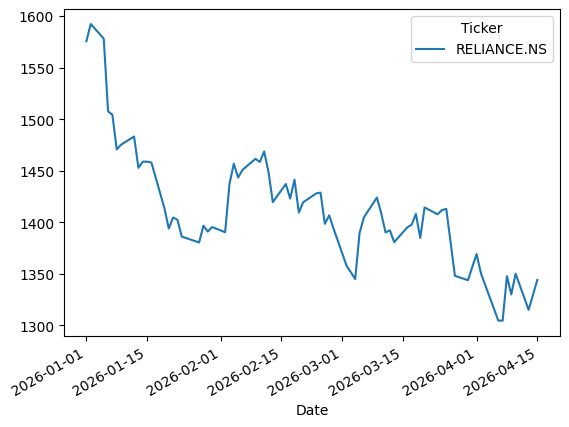

In [67]:
stock_data["Close"].plot()

In [68]:
!pip install mplfinance